# Resolution Sensitivity + Model Misspecification: smooth=1.0 vs smooth=0.5

## Design
**2 (true_smooth) × 4 (resolution) × 2 (fit_smooth) = 16 fits**

| true_smooth | fit_smooth | status |
|---|---|---|
| 1.0 | 1.0 | correctly specified |
| 1.0 | 0.5 | **misspecified** |
| 0.5 | 1.0 | **misspecified** |
| 0.5 | 0.5 | correctly specified |

Resolutions: **x8** (coarsest) → **x4** → **x2** → **x1** (original GEMS grid spacing)

## Kernel formulas (d = phi2 × anisotropic distance)
- **smooth=0.5** (Matérn 1/2): `C = σ² exp(−d)`
- **smooth=1.0** (Matérn ν=1): `C = σ² · √2d · K₁(√2d)`  — evaluated via natural cubic spline

## Lean Hybrid Vecchia conditioning sets (Hybrid_Lean_L08F04_C4F03, offset=0.063)
| Set | Time | Content |
|---|---|---|
| A | t   | spatial NN × 20 |
| B | t−1 | same-loc (1) + local NN (8) + fresh upstream NN (4) |
| C | t−2 | same-loc (1) + local NN (4) + fresh 2× upstream NN (3) |

In [1]:
import gc, os, sys, time, random
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.special import kv as scipy_kv
from sklearn.neighbors import BallTree

LOCAL_SRC  = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
AMAREL_SRC = "/home/jl2815/tco"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings as _orderings
from GEMS_TCO.kernels_vecchia_hybrid import HybridVecchiaFit
from GEMS_TCO.vecchia_st_spline import HybridVecchiaSplineFit
from GEMS_TCO.data_loader import load_data_dynamic_processed

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float64
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
# ── grid / region ──────────────────────────────────────────────────────
DELTA_LAT_BASE = 0.044
DELTA_LON_BASE = 0.063
T_STEPS        = 8

LAT_RANGE = [-3.0,  2.0]
LON_RANGE = [121.0, 131.0]
YEAR  = "2023"
MONTH = 7

HR_LAT_FACTOR  = 100
HR_LON_FACTOR  = 10
RESOLUTION_MULTS = [8, 4, 2, 1]

# ── Lean Vecchia conditioning (Hybrid_Lean_L08F04_C4F03) ──────────────
MM_COND_NUMBER  = 100
NHEADS          = 0
DAILY_STRIDE    = 2
LIMIT_A         = 20
LIMIT_B_LOCAL   = 8
LIMIT_C_LOCAL   = 4
LAG1_FRESH      = 4
LAG2_FRESH      = 3
LAG1_LON_OFFSET = 0.063

# ── optimizer ─────────────────────────────────────────────────────────
LBFGS_STEPS = 6
LBFGS_EVAL  = 20
LBFGS_HIST  = 10
LBFGS_LR    = 1.0

# ── true parameters ───────────────────────────────────────────────────
TRUE_DICT = {
    "sigmasq":    10.0,
    "range_lat":   0.5,
    "range_lon":   0.6,
    "range_time":  2.5,
    "advec_lat":   0.08,
    "advec_lon":  -0.16,
    "nugget":      1.2,
}
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time",
            "advec_lat", "advec_lon", "nugget"]
P_DISP   = [r"$\sigma^2$", r"$r_{lat}$", r"$r_{lon}$", r"$r_{time}$",
            r"$\alpha_{lat}$", r"$\alpha_{lon}$", "nugget"]

TRUE_SMOOTHS = [1.0, 0.5]   # simulation smoothness values
FIT_SMOOTHS  = [1.0, 0.5]   # fitting smoothness values

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Constants ready.", TRUE_DICT)

Constants ready. {'sigmasq': 10.0, 'range_lat': 0.5, 'range_lon': 0.6, 'range_time': 2.5, 'advec_lat': 0.08, 'advec_lon': -0.16, 'nugget': 1.2}


## Helper Functions

In [3]:
# ── parameter reparametrization ────────────────────────────────────────

def true_to_log_params(d):
    phi2 = 1.0 / d["range_lon"]
    phi1 = d["sigmasq"] * phi2
    phi3 = (d["range_lon"] / d["range_lat"]) ** 2
    phi4 = (d["range_lon"] / d["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
            d["advec_lat"], d["advec_lon"], np.log(d["nugget"])]


def backmap_params(out_params):
    p = [float(x.item() if isinstance(x, torch.Tensor) else x) for x in out_params[:7]]
    phi2 = np.exp(p[1]); phi3 = np.exp(p[2]); phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq":    np.exp(p[0]) / phi2,
        "range_lat":  rlon / phi3 ** 0.5,
        "range_lon":  rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat":  p[4],
        "advec_lon":  p[5],
        "nugget":     np.exp(p[6]),
    }


# ── smooth-aware covariance for circulant embedding ────────────────────

def get_covariance_on_grid(lx, ly, lt, params, smooth=0.5):
    """
    Stationary covariance at spatial/temporal lag (lx, ly, lt).
    smooth=0.5: C = (phi1/phi2) * exp(-phi2*d)
    smooth=1.0: C = (phi1/phi2) * sqrt(2)*phi2*d * K1(sqrt(2)*phi2*d)  [via scipy, no grad needed]
    """
    params   = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat    = lx - params[4] * lt
    u_lon    = ly - params[5] * lt
    d        = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    scaled_d = d * phi2

    if smooth == 0.5:
        return (phi1 / phi2) * torch.exp(-scaled_d)

    elif smooth == 1.0:
        # Matérn ν=1: f(r) = sqrt(2)*r * K1(sqrt(2)*r), f(0)=1
        # Use scipy (no autograd needed for simulation)
        sd_np    = scaled_d.detach().cpu().numpy().astype(np.float64)
        sqrt2_sd = np.sqrt(2.0) * sd_np
        safe     = np.where(sqrt2_sd < 1e-10, 1e-10, sqrt2_sd)
        f_vals   = np.where(sqrt2_sd < 1e-10, 1.0, safe * scipy_kv(1, safe))
        f_tensor = torch.tensor(f_vals, dtype=scaled_d.dtype, device=scaled_d.device)
        return (phi1 / phi2) * f_tensor

    else:
        raise ValueError(f"smooth={smooth} not supported (use 0.5 or 1.0)")


def generate_field_values(lats_hr, lons_hr, t_steps, params, dlat, dlon, smooth=0.5):
    """Simulate a GP field via circulant (spectral) embedding."""
    cpu = torch.device("cpu")
    f32 = torch.float32
    nx, ny, nt = len(lats_hr), len(lons_hr), t_steps
    px, py, pt = 2 * nx, 2 * ny, 2 * nt
    lx = torch.arange(px, device=cpu, dtype=f32) * dlat
    lx[px // 2:] -= px * dlat
    ly = torch.arange(py, device=cpu, dtype=f32) * dlon
    ly[py // 2:] -= py * dlon
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    lx_g, ly_g, lt_g = torch.meshgrid(lx, ly, lt, indexing="ij")
    cov  = get_covariance_on_grid(lx_g, ly_g, lt_g, params_cpu, smooth=smooth)
    spec = torch.fft.fftn(cov)
    spec.real = torch.clamp(spec.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(spec.real) * noise).real[:nx, :ny, :nt]
    return field.to(dtype=DTYPE, device=DEVICE)


# ── observation-to-grid mapping (unchanged from original notebook) ─────

def apply_step3_1to1(src_np_valid, grid_coords_np, grid_tree, dlat_half, dlon_half):
    n_grid = len(grid_coords_np)
    if len(src_np_valid) == 0:
        return np.full(n_grid, -1, dtype=np.int64)
    dist_to_cell, cell_for_obs = grid_tree.query(np.radians(src_np_valid), k=1)
    dist_to_cell = dist_to_cell.flatten()
    cell_for_obs = cell_for_obs.flatten()
    assignment   = np.full(n_grid, -1, dtype=np.int64)
    best_dist    = np.full(n_grid, np.inf)
    for obs_i, (cell_j, dist) in enumerate(zip(cell_for_obs, dist_to_cell)):
        if dist < best_dist[cell_j]:
            assignment[cell_j] = obs_i
            best_dist[cell_j]  = dist
    filled = assignment >= 0
    if filled.any():
        win_obs  = assignment[filled]
        lat_diff = np.abs(src_np_valid[win_obs, 0] - grid_coords_np[filled, 0])
        lon_diff = np.abs(src_np_valid[win_obs, 1] - grid_coords_np[filled, 1])
        too_far  = (lat_diff > dlat_half) | (lon_diff > dlon_half)
        assignment[np.where(filled)[0][too_far]] = -1
    return assignment


def precompute_mapping_indices(ref_day_map, lats_hr, lons_hr,
                               grid_coords, sorted_keys, dlat_half, dlon_half):
    hr_lat_g, hr_lon_g = torch.meshgrid(lats_hr, lons_hr, indexing="ij")
    hr_coords_np  = torch.stack([hr_lat_g.flatten(), hr_lon_g.flatten()], dim=1).cpu().numpy()
    hr_tree       = BallTree(np.radians(hr_coords_np), metric="haversine")
    grid_coords_np = grid_coords.cpu().numpy()
    n_grid         = len(grid_coords_np)
    grid_tree      = BallTree(np.radians(grid_coords_np), metric="haversine")
    s3_list, hr_list, src_list = [], [], []
    for key in sorted_keys:
        df = ref_day_map.get(key)
        if df is None or len(df) == 0:
            s3_list.append(np.full(n_grid, -1, dtype=np.int64))
            hr_list.append(torch.zeros(0, dtype=torch.long, device=DEVICE))
            src_list.append(torch.zeros((0, 2), dtype=DTYPE, device=DEVICE))
            continue
        src_np       = df[["Source_Latitude", "Source_Longitude"]].values
        valid_mask   = ~np.isnan(src_np).any(axis=1)
        src_np_valid = src_np[valid_mask]
        assignment   = apply_step3_1to1(src_np_valid, grid_coords_np, grid_tree,
                                        dlat_half, dlon_half)
        s3_list.append(assignment)
        if len(src_np_valid) > 0:
            _, hi = hr_tree.query(np.radians(src_np_valid), k=1)
            hr_list.append(torch.tensor(hi.flatten(), device=DEVICE))
        else:
            hr_list.append(torch.zeros(0, dtype=torch.long, device=DEVICE))
        src_list.append(torch.tensor(src_np_valid, device=DEVICE, dtype=DTYPE))
    return s3_list, hr_list, src_list


def assemble_irregular_map(field, s3_list, hr_list, src_list,
                           sorted_keys, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid     = grid_coords.shape[0]
    field_flat = field.reshape(-1, T_STEPS)
    irr_map    = {}
    for t_idx, key in enumerate(sorted_keys):
        t_val    = float(t_offset + t_idx)
        assign   = s3_list[t_idx]
        hr_idx   = hr_list[t_idx]
        src_locs = src_list[t_idx]
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.full((n_grid, 11), float("nan"), device=DEVICE, dtype=DTYPE)
        rows[:, 3]  = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        if hr_idx.shape[0] > 0:
            gp_vals  = field_flat[hr_idx, t_idx]
            sim_vals = gp_vals + torch.randn(hr_idx.shape[0], device=DEVICE, dtype=DTYPE) * nugget_std
            assign_t = torch.tensor(assign, device=DEVICE, dtype=torch.long)
            filled   = assign_t >= 0
            win_obs  = assign_t[filled]
            rows[filled, 0] = src_locs[win_obs, 0]
            rows[filled, 1] = src_locs[win_obs, 1]
            rows[filled, 2] = sim_vals[win_obs]
        irr_map[key] = rows.detach()
    return irr_map


print("Helper functions defined.")

Helper functions defined.


## Load Real GEMS Observation Patterns

In [4]:
is_amarel   = os.path.exists(config.amarel_data_load_path)
data_path   = config.amarel_data_load_path if is_amarel else config.mac_data_load_path
data_loader = load_data_dynamic_processed(data_path)

df_map, _, _, _ = data_loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=MM_COND_NUMBER,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=False,
)
print(f"Loaded {len(df_map)} time slots for {YEAR}-{MONTH:02d}")

yr2      = YEAR[2:]
tco_path = Path(data_path) / f"pickle_{YEAR}" / f"tco_grid_{yr2}_{MONTH:02d}.pkl"
if tco_path.exists():
    with open(tco_path, "rb") as f:
        tco_map = pickle.load(f)
    print(f"Loaded tco_grid: {len(tco_map)} slots")
else:
    tco_map = {}
    print(f"[WARN] tco_grid not found: {tco_path}")

all_sorted = sorted(df_map.keys())
day_keys   = all_sorted[:T_STEPS]
ref_day    = {k: tco_map.get(k.split("_", 2)[-1], pd.DataFrame()) for k in day_keys}
print(f"Day pattern: {day_keys[0]} … {day_keys[-1]}")

--- Global Monthly Mean for 2023-7: 249.7131 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
Loaded 248 time slots for 2023-07
Loaded tco_grid: 248 slots
Day pattern: 2023_07_y23m07day01_hm00:53 … 2023_07_y23m07day01_hm07:48


## Setup High-Resolution Grid + Simulate Both Fields

In [5]:
dlat_hr = DELTA_LAT_BASE / HR_LAT_FACTOR
dlon_hr = DELTA_LON_BASE / HR_LON_FACTOR
lats_hr = torch.arange(LAT_RANGE[0] - 0.1, LAT_RANGE[1] + 0.1, dlat_hr, device=DEVICE, dtype=DTYPE)
lons_hr = torch.arange(LON_RANGE[0] - 0.1, LON_RANGE[1] + 0.1, dlon_hr, device=DEVICE, dtype=DTYPE)
print(f"High-res grid: {len(lats_hr)} lat × {len(lons_hr)} lon = {len(lats_hr)*len(lons_hr):,} cells")

true_log    = true_to_log_params(TRUE_DICT)
true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
print("True log-params:", [f"{v:.4f}" for v in true_log])

fields = {}
for ts in TRUE_SMOOTHS:
    print(f"Simulating field from smooth={ts}...", end=" ")
    t0 = time.time()
    torch.manual_seed(SEED)
    fields[ts] = generate_field_values(
        lats_hr, lons_hr, T_STEPS, true_params, dlat_hr, dlon_hr, smooth=ts
    )
    print(f"Done in {time.time()-t0:.1f}s | shape={tuple(fields[ts].shape)}")

High-res grid: 11819 lat × 1620 lon = 19,146,780 cells
True log-params: ['2.8134', '0.5108', '0.3646', '-2.8542', '0.0800', '-0.1600', '0.1823']
Simulating field from smooth=1.0... Done in 362.3s | shape=(11819, 1620, 8)
Simulating field from smooth=0.5... Done in 77.4s | shape=(11819, 1620, 8)


## Build Resolution Setups (grid, ordering, obs mapping)

In [6]:
base_setups = {}

for R in RESOLUTION_MULTS:
    dlat = DELTA_LAT_BASE * R
    dlon = DELTA_LON_BASE * R
    print(f"\nx{R}: spacing={dlat:.4f}° lat × {dlon:.4f}° lon")

    lats_g = torch.arange(LAT_RANGE[0], LAT_RANGE[1] + 1e-4, dlat, device=DEVICE, dtype=DTYPE)
    lons_g = torch.arange(LON_RANGE[0], LON_RANGE[1] + 1e-4, dlon, device=DEVICE, dtype=DTYPE)
    lats_g = torch.round(lats_g * 10000) / 10000
    lons_g = torch.round(lons_g * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats_g, lons_g, indexing="ij")
    grid_coords  = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    n_grid       = grid_coords.shape[0]
    print(f"  Grid: {len(lats_g)} lat × {len(lons_g)} lon = {n_grid} cells")

    coords_np         = grid_coords.cpu().numpy()
    ord_grid          = _orderings.maxmin_cpp(coords_np)
    nns_grid          = _orderings.find_nns_l2(locs=coords_np[ord_grid], max_nn=MM_COND_NUMBER)
    ordered_coords_np = coords_np[ord_grid]

    s3_list, hr_list, src_list = precompute_mapping_indices(
        ref_day, lats_hr, lons_hr, grid_coords,
        day_keys, dlat_half=dlat / 2, dlon_half=dlon / 2
    )

    n_obs_total = sum(int(np.sum(a >= 0)) for a in s3_list)
    print(f"  Matched obs: {n_obs_total} total ({n_obs_total/T_STEPS:.0f}/step avg)")

    base_setups[R] = {
        "grid_coords": grid_coords, "ord_grid": ord_grid,
        "nns_grid": nns_grid, "ordered_coords_np": ordered_coords_np,
        "n_grid": n_grid,
        "s3_list": s3_list, "hr_list": hr_list, "src_list": src_list,
        "n_obs_total": n_obs_total, "dlat": dlat, "dlon": dlon,
    }
    gc.collect()

print("\nResolution setups complete.")


x8: spacing=0.3520° lat × 0.5040° lon
  Grid: 15 lat × 20 lon = 300 cells
  Matched obs: 2400 total (300/step avg)

x4: spacing=0.1760° lat × 0.2520° lon
  Grid: 29 lat × 40 lon = 1160 cells
  Matched obs: 9266 total (1158/step avg)

x2: spacing=0.0880° lat × 0.1260° lon
  Grid: 57 lat × 80 lon = 4560 cells
  Matched obs: 36256 total (4532/step avg)

x1: spacing=0.0440° lat × 0.0630° lon
  Grid: 114 lat × 159 lon = 18126 cells
  Matched obs: 135917 total (16990/step avg)

Resolution setups complete.


## Assemble Irregular Maps (per true_smooth × resolution)

In [7]:
irr_maps = {}

for ts in TRUE_SMOOTHS:
    for R in RESOLUTION_MULTS:
        setup   = base_setups[R]
        irr_map = assemble_irregular_map(
            fields[ts],
            setup["s3_list"], setup["hr_list"], setup["src_list"],
            day_keys, setup["grid_coords"], true_params,
        )
        irr_maps[(ts, R)] = {k: v[setup["ord_grid"]] for k, v in irr_map.items()}
        del irr_map
        gc.collect()

print("Irregular maps assembled:")
for ts in TRUE_SMOOTHS:
    for R in RESOLUTION_MULTS:
        n_obs = sum(int((~torch.isnan(v[:, 2])).sum()) for v in irr_maps[(ts, R)].values())
        print(f"  true_smooth={ts}, x{R}: {n_obs} obs")

Irregular maps assembled:
  true_smooth=1.0, x8: 2400 obs
  true_smooth=1.0, x4: 9266 obs
  true_smooth=1.0, x2: 36256 obs
  true_smooth=1.0, x1: 135917 obs
  true_smooth=0.5, x8: 2400 obs
  true_smooth=0.5, x4: 9266 obs
  true_smooth=0.5, x2: 36256 obs
  true_smooth=0.5, x1: 135917 obs


## Fitting Loop — 16 Fits

- `fit_smooth=1.0` → `HybridVecchiaSplineFit(smooth=1.0)` (cubic spline Matérn ν=1)
- `fit_smooth=0.5` → `HybridVecchiaFit(smooth=0.5)` (closed-form Matérn 1/2)

Both use **Lean conditioning** (L08F04_C4F03, offset=0.063).

In [8]:
rng      = np.random.default_rng(SEED)
init_log = list(true_log)
for idx in [0, 1, 2, 3, 6]:
    init_log[idx] += rng.uniform(-0.4, 0.4)
for idx in [4, 5]:
    scale = max(abs(init_log[idx]), 0.05)
    init_log[idx] += rng.uniform(-scale, scale)
init_phys = backmap_params(init_log)
print("Initial params (physical):")
for k in P_LABELS:
    print(f"  {k:12s}: init={init_phys[k]:.4f}  true={TRUE_DICT[k]:.4f}")

Initial params (physical):
  sigmasq     : init=13.0743  true=10.0000
  range_lat   : init=0.4549  true=0.5000
  range_lon   : init=0.6301  true=0.6000
  range_time  : init=2.4260  true=2.5000
  advec_lat   : init=0.1561  true=0.0800
  advec_lon   : init=-0.0764  true=-0.1600
  nugget      : init=0.8673  true=1.2000


In [9]:
results = []

for ts in TRUE_SMOOTHS:
    for R in RESOLUTION_MULTS:
        setup       = base_setups[R]
        irr_map_ord = irr_maps[(ts, R)]

        for fs in FIT_SMOOTHS:
            correctly_specified = (ts == fs)
            spec_label = "CORRECT" if correctly_specified else "MISSPEC"
            tag = f"true={ts}  fit={fs}  x{R}  [{spec_label}]"
            print(f"\n{'='*65}")
            print(f"Fitting: {tag}")
            print(f"  n_obs={setup['n_obs_total']}  n_grid={setup['n_grid']}")

            params = [
                torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True)
                for v in init_log
            ]

            # ── select model based on fit_smooth ──────────────────────
            lean_kwargs = dict(
                input_map=irr_map_ord,
                nns_map=setup["nns_grid"],
                mm_cond_number=MM_COND_NUMBER,
                nheads=NHEADS,
                limit_A=LIMIT_A,
                limit_B_local=LIMIT_B_LOCAL,
                limit_C_local=LIMIT_C_LOCAL,
                daily_stride=DAILY_STRIDE,
                spatial_coords=setup["ordered_coords_np"],
                lag1_lon_offset=LAG1_LON_OFFSET,
                lag1_fresh_count=LAG1_FRESH,
                lag2_fresh_count=LAG2_FRESH,
            )

            if fs == 1.0:
                model = HybridVecchiaSplineFit(smooth=1.0, **lean_kwargs)
            else:  # fs == 0.5
                model = HybridVecchiaFit(smooth=0.5, **lean_kwargs)

            model.precompute_conditioning_sets()

            optimizer = model.set_optimizer(
                params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST
            )
            t0  = time.time()
            out, fit_iter = model.fit_vecc_lbfgs(
                params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5
            )
            elapsed = time.time() - t0

            loss = float(out[-1])
            est  = backmap_params(out)
            print(f"  loss={loss:.4f}  elapsed={elapsed:.1f}s  steps={fit_iter+1}")
            for k in P_LABELS:
                re = abs(est[k] - TRUE_DICT[k]) / max(abs(TRUE_DICT[k]), 0.01)
                print(f"    {k:12s}: est={est[k]:8.4f}  true={TRUE_DICT[k]:8.4f}  re={re:.3f}")

            results.append({
                "true_smooth":         ts,
                "fit_smooth":          fs,
                "correctly_specified": correctly_specified,
                "R":                   R,
                "n_obs_total":         setup["n_obs_total"],
                "n_grid":              setup["n_grid"],
                "loss":                loss,
                "fit_steps":           fit_iter + 1,
                "elapsed_s":           round(elapsed, 1),
                **{f"est_{k}": est[k] for k in P_LABELS},
            })
            del model
            gc.collect()

df = pd.DataFrame(results)
print(f"\nDone. {len(df)} fits recorded.")


Fitting: true=1.0  fit=1.0  x8  [CORRECT]
  n_obs=2400  n_grid=300
[HybridVecchiaSplineFit] Matérn ν=1 spline built: 500 knots, r_max=15.0, f(0)=1.0000, f(1)=0.4443, device=cpu
Pre-computing HybridVecchia (smooth=1.0) [A=20, AB=33, ABC=41, B=local8+fresh4, C=local4+fresh3, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.5401] [SetC=True] Done. (Heads=0, Tails A/AB/ABC=300/300/1800)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/6 / Loss: 1.401877 ---
  Param 0: Value=2.8541, Grad=-2.708488178427746e-05
  Param 1: Value=0.5458, Grad=-0.0006078375385399622
  Param 2: Value=0.4064, Grad=-0.00020378421144902456
  Param 3: Value=-3.0931, Grad=-0.00017756375535542442
  Param 4: Value=0.0966, Grad=-0.0024488484822381973
  Param 5: Value=-0.1679, Grad=0.0005362865759716839
  Param 6: Value=0.0851, Grad=-0.00012220441774473534
  Max Abs Grad: 2.448848e-03
------------------------------
--- Step 2/6 / Loss: 1.384277 ---
  Param 0: Value=2.8524, Grad=1.0746220454012963e-06
  Param 

## Results Summary

In [10]:
for k in P_LABELS:
    tv = TRUE_DICT[k]
    denom = max(abs(tv), 0.01)
    df[f"re_{k}"] = (df[f"est_{k}"] - tv).abs() / denom

re_cols = [f"re_{k}" for k in P_LABELS]
df["overall_rmsre"] = np.sqrt(df[re_cols].pow(2).mean(axis=1))

disp = df[["true_smooth", "fit_smooth", "R", "n_obs_total",
           "overall_rmsre", "loss", "elapsed_s"] + re_cols].copy()
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
print(disp.sort_values(["true_smooth", "fit_smooth", "R"]).to_string(index=False))

 true_smooth  fit_smooth  R  n_obs_total  overall_rmsre   loss  elapsed_s  re_sigmasq  re_range_lat  re_range_lon  re_range_time  re_advec_lat  re_advec_lon  re_nugget
      0.5000      0.5000  1       135917         0.0791 1.1142   142.5000      0.0932        0.1127        0.0864         0.1071        0.0430        0.0373     0.0162
      0.5000      0.5000  2        36256         0.1279 1.2552    44.4000      0.0893        0.1047        0.0841         0.1220        0.2624        0.0654     0.0231
      0.5000      0.5000  4         9266         0.1662 1.4260    12.5000      0.1261        0.1617        0.1479         0.2515        0.2268        0.0613     0.1052
      0.5000      0.5000  8         2400         0.1522 1.4837     3.4000      0.0229        0.0675        0.0040         0.0364        0.3621        0.0164     0.1563
      0.5000      1.0000  1       135917         0.2869 1.2289   157.7000      0.0974        0.3064        0.3323         0.3066        0.0280        0.0363    

In [11]:
pivot = df.pivot_table(
    index=["true_smooth", "fit_smooth", "correctly_specified"],
    columns="R",
    values="overall_rmsre",
)
pivot.columns = [f"x{c}" for c in pivot.columns]
pivot = pivot.reindex(columns=[f"x{r}" for r in RESOLUTION_MULTS])
print("Overall RMSRE (lower = better):")
print(pivot.to_string())

Overall RMSRE (lower = better):
                                               x8     x4     x2     x1
true_smooth fit_smooth correctly_specified                            
0.5000      0.5000     True                0.1522 0.1662 0.1279 0.0791
            1.0000     False               0.5543 0.5154 0.3254 0.2869
1.0000      0.5000     False               0.4183 0.5557 0.5573 0.8427
            1.0000     True                0.0999 0.2095 0.0850 0.0510


## Plot 1 — Parameter Trajectories Across Resolutions

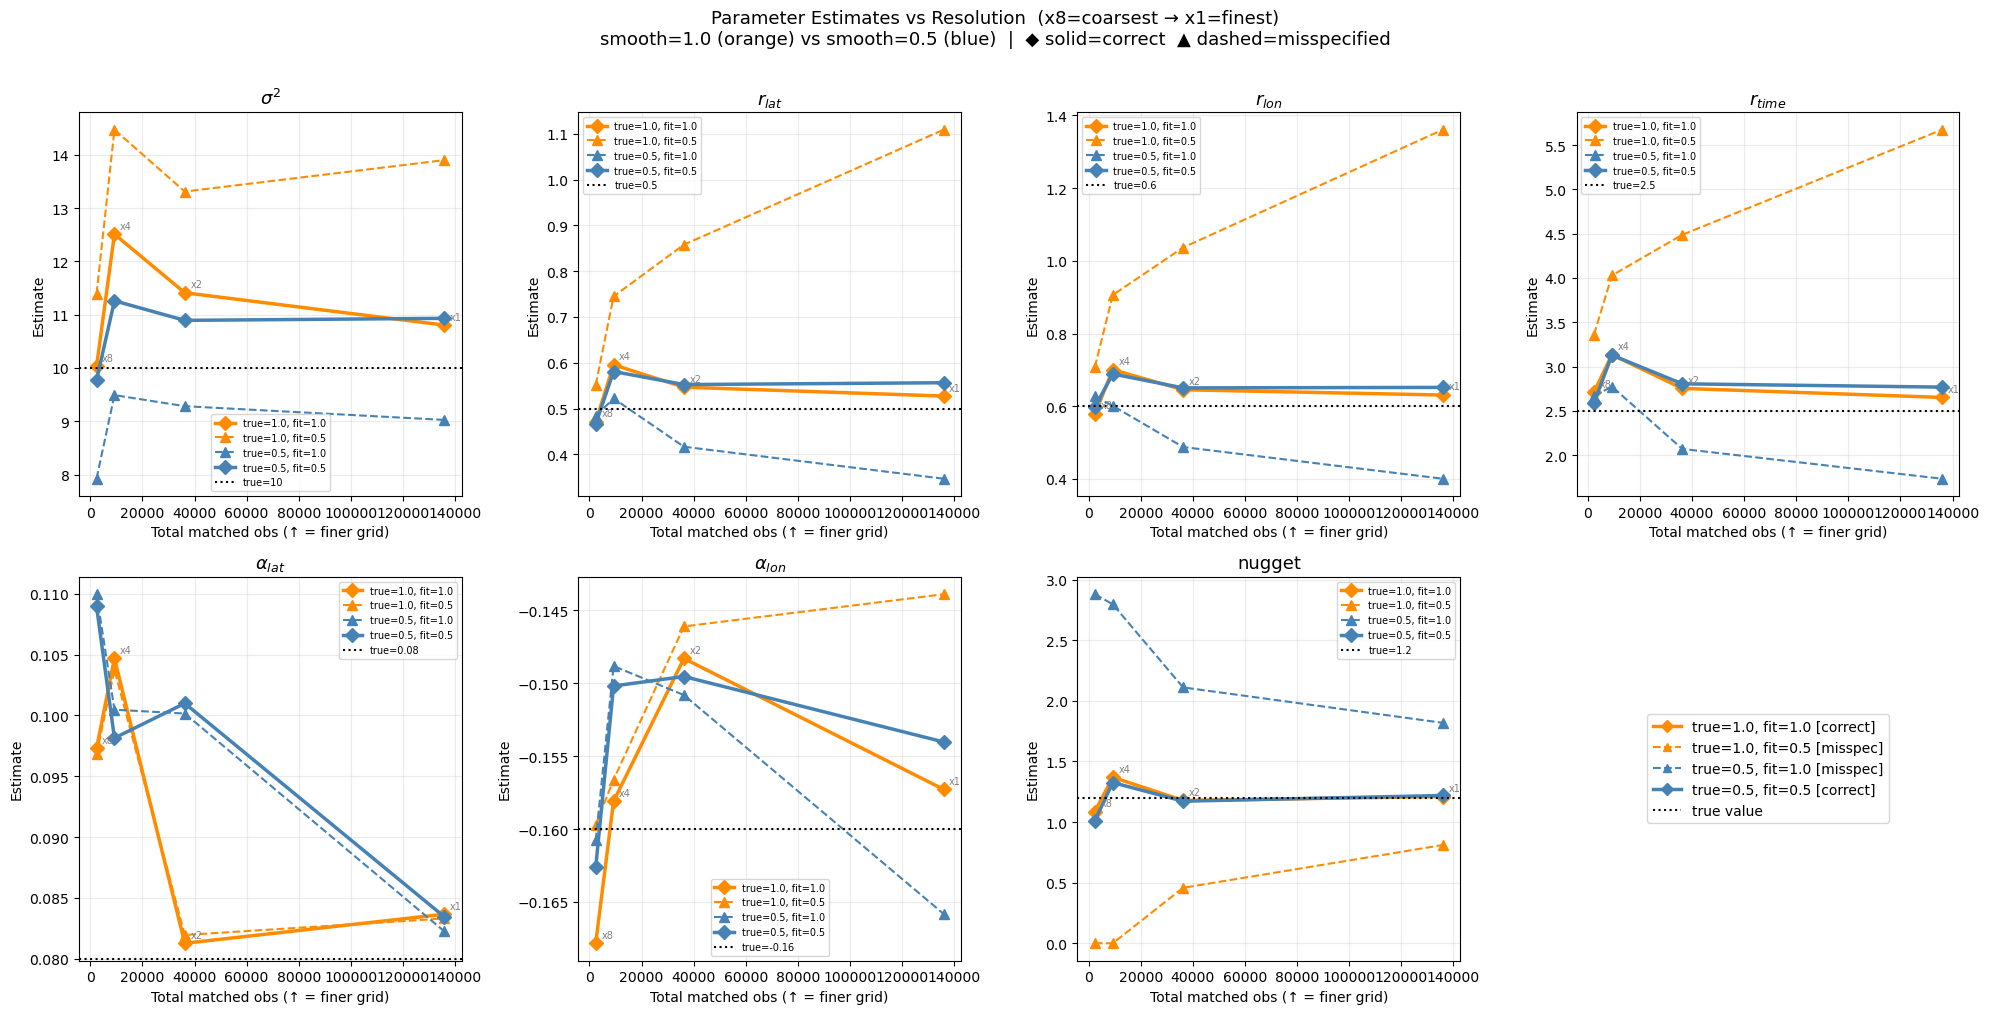

Saved: param_trajectories_10vs05.png


In [12]:
COLOR = {1.0: "darkorange", 0.5: "steelblue"}
LS    = {True: "-",  False: "--"}
LW    = {True: 2.5,  False: 1.5}
MK    = {True: "D",  False: "^"}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (param, plabel) in enumerate(zip(P_LABELS, P_DISP)):
    ax = axes[i]
    tv = TRUE_DICT[param]

    for ts in TRUE_SMOOTHS:
        for fs in FIT_SMOOTHS:
            sub     = df[(df.true_smooth == ts) & (df.fit_smooth == fs)].sort_values("n_obs_total")
            correct = (ts == fs)
            ax.plot(
                sub["n_obs_total"], sub[f"est_{param}"],
                color=COLOR[ts], ls=LS[correct], lw=LW[correct],
                marker=MK[correct], ms=7,
                label=f"true={ts}, fit={fs}",
            )
            if correct and ts == 1.0:
                for _, row in sub.iterrows():
                    ax.annotate(
                        f"x{int(row.R)}",
                        (row["n_obs_total"], row[f"est_{param}"]),
                        textcoords="offset points", xytext=(4, 4),
                        fontsize=7, color="grey",
                    )

    ax.axhline(tv, color="black", ls=":", lw=1.5, label=f"true={tv:.3g}")
    ax.set_title(plabel, fontsize=13)
    ax.set_xlabel("Total matched obs (↑ = finer grid)")
    ax.set_ylabel("Estimate")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.25)

axes[-1].set_visible(False)
legend_entries = [
    mlines.Line2D([], [], color=COLOR[1.0], ls="-",  lw=2.5, marker="D", label="true=1.0, fit=1.0 [correct]"),
    mlines.Line2D([], [], color=COLOR[1.0], ls="--", lw=1.5, marker="^", label="true=1.0, fit=0.5 [misspec]"),
    mlines.Line2D([], [], color=COLOR[0.5], ls="--", lw=1.5, marker="^", label="true=0.5, fit=1.0 [misspec]"),
    mlines.Line2D([], [], color=COLOR[0.5], ls="-",  lw=2.5, marker="D", label="true=0.5, fit=0.5 [correct]"),
    mlines.Line2D([], [], color="black",    ls=":",  lw=1.5,             label="true value"),
]
axes[-1].legend(handles=legend_entries, loc="center", fontsize=10, frameon=True)
axes[-1].set_visible(True)
axes[-1].axis("off")

fig.suptitle(
    "Parameter Estimates vs Resolution  (x8=coarsest → x1=finest)\n"
    "smooth=1.0 (orange) vs smooth=0.5 (blue)  |  ◆ solid=correct  ▲ dashed=misspecified",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig("param_trajectories_10vs05.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: param_trajectories_10vs05.png")

## Plot 2 — Relative Error Heatmap

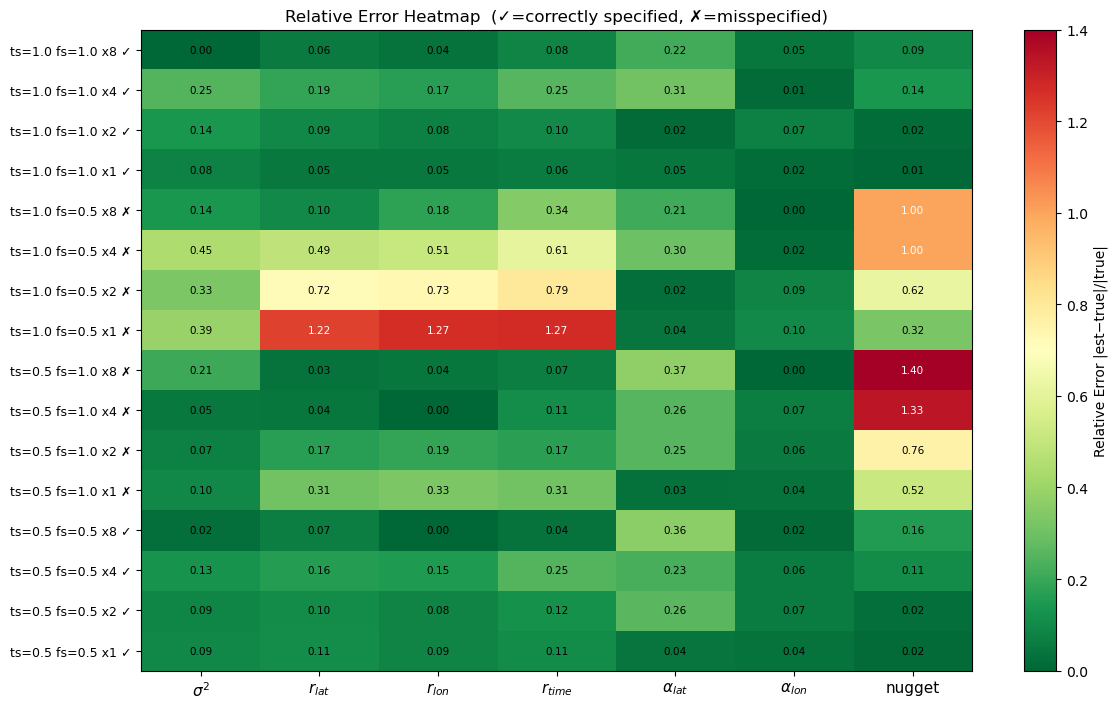

Saved: re_heatmap_10vs05.png


In [13]:
combo_labels = []
re_matrix    = []

for ts in TRUE_SMOOTHS:
    for fs in FIT_SMOOTHS:
        for R in RESOLUTION_MULTS:
            row = df[(df.R == R) & (df.true_smooth == ts) & (df.fit_smooth == fs)]
            if row.empty:
                continue
            row = row.iloc[0]
            re_vec = [row[f"re_{k}"] for k in P_LABELS]
            spec   = "✓" if ts == fs else "✗"
            combo_labels.append(f"ts={ts} fs={fs} x{R} {spec}")
            re_matrix.append(re_vec)

re_matrix = np.array(re_matrix)

fig, ax = plt.subplots(figsize=(12, max(4, len(combo_labels) * 0.45)))
im = ax.imshow(re_matrix, aspect="auto", cmap="RdYlGn_r",
               vmin=0, vmax=min(re_matrix.max(), 1.5))
plt.colorbar(im, ax=ax, label="Relative Error |est−true|/|true|")
ax.set_xticks(range(len(P_LABELS)))
ax.set_xticklabels(P_DISP, fontsize=11)
ax.set_yticks(range(len(combo_labels)))
ax.set_yticklabels(combo_labels, fontsize=9)
for r in range(re_matrix.shape[0]):
    for c in range(re_matrix.shape[1]):
        val = re_matrix[r, c]
        ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color="white" if val > 0.8 else "black")
ax.set_title("Relative Error Heatmap  (✓=correctly specified, ✗=misspecified)", fontsize=12)
plt.tight_layout()
plt.savefig("re_heatmap_10vs05.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: re_heatmap_10vs05.png")

## Summary Analysis

In [14]:
print("=" * 70)
print("RESOLUTION SENSITIVITY: smooth=1.0 vs smooth=0.5")
print("=" * 70)
for ts in TRUE_SMOOTHS:
    for fs in FIT_SMOOTHS:
        sub  = df[(df.true_smooth == ts) & (df.fit_smooth == fs)].sort_values("n_obs_total")
        spec = "CORRECT" if ts == fs else "MISSPEC"
        print(f"\ntrue_smooth={ts}, fit_smooth={fs} [{spec}]")
        print(f"  {'n_obs':>8}  {'RMSRE':>8}  {'range_lon':>10}  {'nugget':>8}  {'advec_lon':>10}")
        for _, row in sub.iterrows():
            print(f"  {int(row.n_obs_total):>8}  "
                  f"{row.overall_rmsre:>8.4f}  "
                  f"{row.est_range_lon:>10.4f}  "
                  f"{row.est_nugget:>8.4f}  "
                  f"{row.est_advec_lon:>10.4f}")

print("\n" + "=" * 70)
print("MISSPECIFICATION EFFECT at finest resolution (x1)")
print("=" * 70)
finest = df[df.R == 1]
for _, row in finest.iterrows():
    spec = "CORRECT" if row.correctly_specified else "MISSPEC"
    print(f"ts={row.true_smooth}, fs={row.fit_smooth} [{spec}]: "
          f"range_lon={row.est_range_lon:.4f} (true={TRUE_DICT['range_lon']:.4f})  "
          f"nugget={row.est_nugget:.4f} (true={TRUE_DICT['nugget']:.4f})  "
          f"RMSRE={row.overall_rmsre:.4f}")

RESOLUTION SENSITIVITY: smooth=1.0 vs smooth=0.5

true_smooth=1.0, fit_smooth=1.0 [CORRECT]
     n_obs     RMSRE   range_lon    nugget   advec_lon
      2400    0.0999      0.5787    1.0869     -0.1678
      9266    0.2095      0.7004    1.3697     -0.1581
     36256    0.0850      0.6454    1.1785     -0.1483
    135917    0.0510      0.6308    1.2106     -0.1573

true_smooth=1.0, fit_smooth=0.5 [MISSPEC]
     n_obs     RMSRE   range_lon    nugget   advec_lon
      2400    0.4183      0.7078    0.0000     -0.1597
      9266    0.5557      0.9059    0.0000     -0.1566
     36256    0.5573      1.0366    0.4577     -0.1461
    135917    0.8427      1.3607    0.8106     -0.1439

true_smooth=0.5, fit_smooth=1.0 [MISSPEC]
     n_obs     RMSRE   range_lon    nugget   advec_lon
      2400    0.5543      0.6269    2.8800     -0.1608
      9266    0.5154      0.6012    2.7975     -0.1488
     36256    0.3254      0.4878    2.1113     -0.1508
    135917    0.2869      0.4006    1.8190     -0.16